# $$Convolutional-Neural-Network(CNN)$$

- are a class of algorithms that are used to process grid-like data e.g. Images
- founding stone for Computer Vision
- Computer vision is the ability of a computer to see
- if you are able to process grid like data, anything coming from a camera can be processed as well
- 
- these algorithms use Convolution operation - 
- we will use Tensorflow to implement CNNs
- 

Convolution can be used successively across the cells of a matrix to create a new matrix


No Padding - only the original matrix is used

Half Padding - padding around part of the matrix is used

Full Padding - padding around the full matrix is used


- convolution, we create small kernels to slide over larger grid like data, to produce new outputs
- its just mathematical
- in case of images, it is just `image processing`
    - taken an image, and put a filter on it?
    - 



### CNN architecture
- Typical cnn architecture consists of two types of layers:
    - Convolutional Tool - will help in feature extraction
    - Fully Connected layer - will help in processing and predicting

- Types of operation you would see in CNNs:
1. Convolutional Layers -
    - layers which will apply convolutional operations
    - Detect features edges, textures, patterns
    - spatial relationship ---> at an edge, pixel on left and pixel on the right will have sharp intensity changes ---> 34 >>> 203 --- sharp increase --- if you dont keep them side by side, an edge will not form
    - their spatial position is important --> has details
2. Pooling Layers - These are not layers --- because they don't have any weights! no neurons
    - Operations used to downsample images
    - reduce complexity for the NN
    - min, max and average pooling
3. Dropout Layers - These are not layers --- because they don't have any weights! no neurons
    - are used to avoid overfitting
    - remove a few neurons from the network randomly
    - if there were neurons of set weight, that decided the prediction
    - gives chance for other neurons to learn, update weights, thus reduce the memorization
    - NNs tend to memorize a lot

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

In [2]:
(X_train, y_train) , (X_test, y_test) = mnist.load_data() # brings 70K images to us

# [(array of shape 60000, 28 x 28)]-----> 60K 2d arrays
# # [(array of shape 600000,)]
# [(array of shape 10000, 28 x 28)]-----> 60K 2d arrays
# # [(array of shape 100000,)]

In [39]:
np.set_printoptions(linewidth=200)
print(X_train[10])
print(y_train[10])

[[[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0. 

TypeError: 'Axes' object is not subscriptable

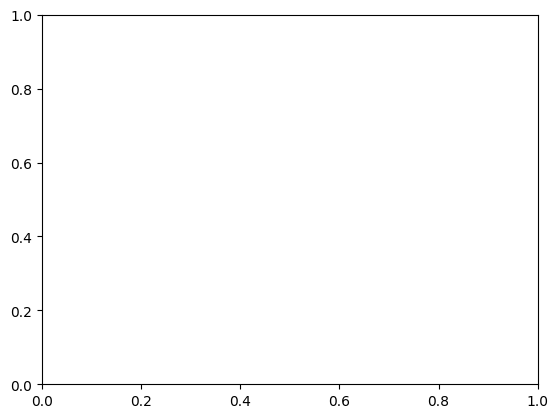

In [ ]:

img_num = 80
x = X_train[img_num] # 28 x 28

smiley = y_train[img_num]

fig, ax = plt.subplots(1,1)

ax[0].imshow(smiley, cmap='gray', vmin=0, vmax=255)

for i in range(28):
    for j in range(28):
        ax.text(j, i, str(smiley[i,j]), ha='center', va='center',
                     fontsize=10, color='red', fontweight='bold')
    
plt.show()

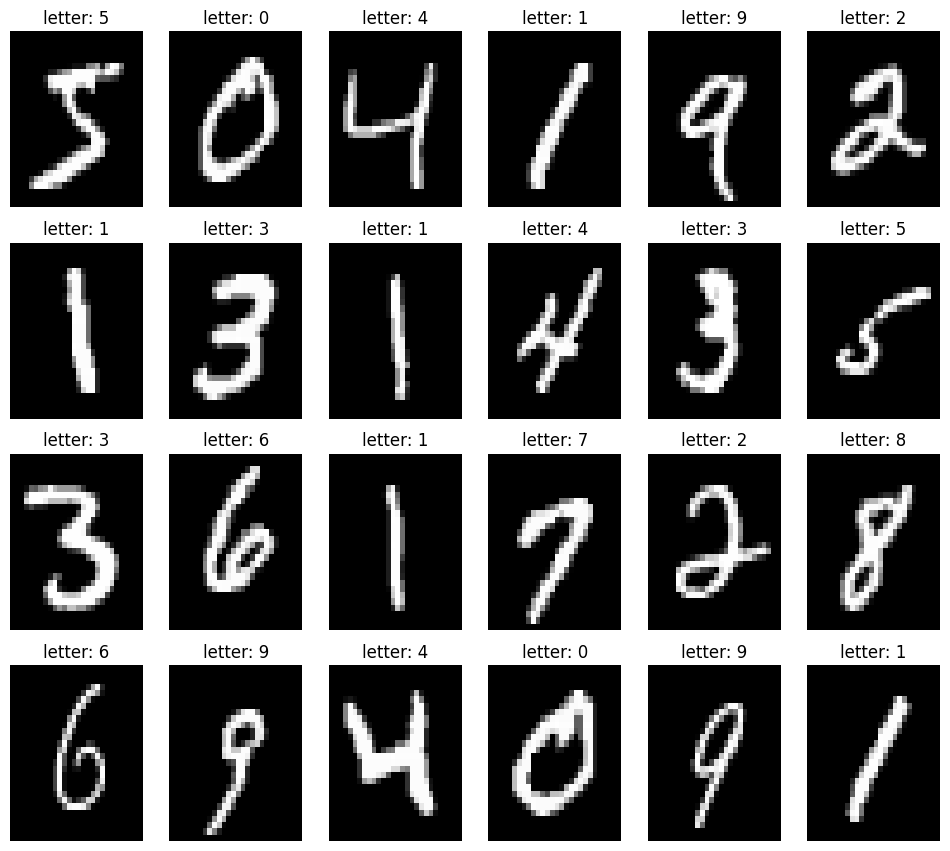

In [45]:
# observe the images

plt.figure(figsize= (12,16)) # width x height  # 4 x 4

for i in range(24):    
    # subplots
    plt.subplot(6,6, i + 1)
    sns.heatmap(X_train[i], cmap='gray', cbar= False, xticklabels= False, yticklabels=False)
    plt.title(f"letter: {y_train[i]}")

### CNNs in tensorflow

In [22]:
import warnings
warnings.filterwarnings('ignore')

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers 
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dropout

Shape of our input data:
- 600000, 28 , 28
- Batch_size , height, width

Our Neural Network in TF accepts:
- Batch, Height, Width, Channels
- 60K, 28, 28, 1
- Why channels = 1 ----> MNIST is grayscale images
- channels = 3, color images, RGB channels
- 



In [41]:
(X_train, y_train) , (X_test, y_test) = mnist.load_data()

In [42]:
X_train.shape
X_test.shape

(10000, 28, 28)

In [ ]:
# Reshaping the input --- to match NN input size
# for gray scale images

X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

In [43]:
# Scaling ---- NNs do better with scaled data that is closer towards 0

X_train = X_train/255
X_test = X_test/255

In [51]:
# NN
model = Sequential([
    
    # step 1 ==== Detects Edges, basic shapes 
    layers.Conv2D(32, (3,3), input_shape = (28,28, 1), activation ='relu' ), # have weights 
    layers.MaxPool2D(pool_size= (2,2)), # no weights

    # step 2 === Complex features detection
    layers.Conv2D(64, kernel_size=(3,3), activation= 'relu'),
    layers.MaxPool2D(pool_size= (2,2)),

    # step 3 === convert it into 1D --- Flattening for the classifier
    layers.Flatten(),

    # Step 4 === Thinking layer
    layers.Dense(128, activation= 'relu'),
    layers.Dropout(0.2), # shut off 20% of the neurons

    # step 5 ==== Output layer for 10 digits --- 0 to 9
    layers.Dense(10, activation= 'softmax')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Training

history = model.fit(X_train, y_train,
                    epochs = 10, 
                    batch_size = 64, 
                    validation_split = 0.2,
                    verbose = 1
                    )

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9395 - loss: 0.2031 - val_accuracy: 0.9831 - val_loss: 0.0615
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9815 - loss: 0.0615 - val_accuracy: 0.9855 - val_loss: 0.0494
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9862 - loss: 0.0424 - val_accuracy: 0.9870 - val_loss: 0.0415
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9892 - loss: 0.0336 - val_accuracy: 0.9864 - val_loss: 0.0450
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9919 - loss: 0.0260 - val_accuracy: 0.9895 - val_loss: 0.0374
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9933 - loss: 0.0207 - val_accuracy: 0.9896 - val_loss: 0.0421
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9942 - loss: 0.0179 - val_accuracy: 0.9908 - val_loss: 0.0337
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9951 - loss: 0.0144 - 

In [57]:
# evaluation
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy = {test_accuracy*100:.2f}%')


# making predictions
y_pred = model.predict(X_test)
y_class = [np.argmax(i) for i in y_pred]


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9915 - loss: 0.0271
Accuracy = 99.15%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [59]:
from sklearn.metrics import classification_report
cr = classification_report(y_class, y_test)
print(cr)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       975
           1       1.00      1.00      1.00      1134
           2       0.99      0.99      0.99      1034
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       983
           5       0.99      0.99      0.99       894
           6       0.99      0.99      0.99       957
           7       0.99      0.98      0.99      1037
           8       0.99      1.00      0.99       966
           9       0.99      0.99      0.99      1010

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [60]:
# save the model
model.save('digit-recognition-model.keras')

In [61]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)